# Trực quan hóa dữ liệu nhà hàng — Tháng 11/2025

**File dữ liệu:** `du_lieu_nha_hang_t11_2025.csv`

Notebook này dùng thư viện **Seaborn** để khám phá và trực quan hóa dữ liệu hóa đơn nhà hàng, gồm:
- Số lượng khách, giới tính (Nam/Nữ)
- Trị giá hóa đơn
- Thời gian vào/ra
- Hình thức thanh toán
- Loại ngày (ngày thường / cuối tuần)

Tất cả số liệu được hiển thị theo định dạng số Việt Nam (dấu chấm ngăn cách hàng nghìn, ví dụ: `1.000.000`).


## 1. Import thư viện và thiết lập

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.unicode_minus"] = False

# Hàm định dạng số kiểu Việt Nam: dấu chấm ngăn cách hàng nghìn (1.000.000)
def dinh_dang_so_vn(x, pos=None):
    return f"{x:,.0f}".replace(",", ".")

VN_FORMATTER = mticker.FuncFormatter(dinh_dang_so_vn)

def dat_dinh_dang_truc(ax, truc="y"):
    """Áp định dạng số Việt Nam cho trục x hoặc y của biểu đồ."""
    if truc in ("y", "ca_hai"):
        ax.yaxis.set_major_formatter(VN_FORMATTER)
    if truc in ("x", "ca_hai"):
        ax.xaxis.set_major_formatter(VN_FORMATTER)

def in_so_vn(x):
    """Trả về chuỗi số định dạng Việt Nam, dùng khi in kết quả text."""
    if isinstance(x, float) and not x.is_integer():
        phan_nguyen, phan_le = f"{x:,.2f}".split(".")
        return phan_nguyen.replace(",", ".") + "," + phan_le
    return f"{x:,.0f}".replace(",", ".")


## 2. Đọc dữ liệu

File CSV này được lưu ở định dạng **UTF-16 LE** (có BOM `FF FE`), không phải UTF-8 thông thường.
Đoạn code dưới tự động nhận diện encoding bằng cách đọc 2 byte đầu tiên trước khi nạp dữ liệu, tránh lỗi `UnicodeDecodeError`.


In [2]:
duong_dan_file = "C:\document\Study documents\Data visualizaion\data\du_lieu_nha_hang_t11_2025.csv"

# Tự động nhận diện encoding (UTF-16 LE có BOM FF FE, ngược lại dùng UTF-8)
with open(duong_dan_file, "rb") as f:
    bom = f.read(2)

if bom == b"\xff\xfe":
    encoding = "utf-16"
else:
    encoding = "utf-8"

print(f"Encoding phát hiện: {encoding}")

df = pd.read_csv(duong_dan_file, encoding=encoding)

print(f"Kích thước dữ liệu: {df.shape[0]:,} dòng x {df.shape[1]} cột".replace(",", "."))
df.head()


Encoding phát hiện: utf-16
Kích thước dữ liệu: 10.000 dòng x 9 cột


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\TDV\AppData\Local\Temp\ipykernel_37452\427028558.py:1: SyntaxWarning: invalid escape sequence '\d'
  duong_dan_file = "C:\document\Study documents\Data visualizaion\data\du_lieu_nha_hang_t11_2025.csv"


,STT,Số lượng khách,Trị giá hóa đơn,Nam,Nữ,Ngày giờ vào,Ngày giờ ra,Thanh toán,Loại ngày
0,1,2,556634,0,2,2025-11-08 19:29,2025-11-08 20:34,Tiền mặt,Cuối tuần
1,2,2,514704,2,0,2025-11-05 19:39,2025-11-05 21:14,Chuyển khoản,Ngày thường
2,3,4,973256,4,0,2025-11-28 12:31,2025-11-28 13:59,Chuyển khoản,Ngày thường
3,4,6,946230,4,2,2025-11-15 13:10,2025-11-15 14:26,Tiền mặt,Cuối tuần
4,5,6,1839210,4,2,2025-11-29 18:06,2025-11-29 19:14,Tiền mặt,Cuối tuần


## 3. Tiền xử lý dữ liệu

- Chuyển `Ngày giờ vào` và `Ngày giờ ra` sang kiểu `datetime`.
- Tạo thêm cột **Thời lượng dùng bữa (phút)** = Ngày giờ ra − Ngày giờ vào.
- Tạo thêm cột **Giờ vào** (khung giờ trong ngày) để phân tích theo thời gian.


In [3]:
df["Ngày giờ vào"] = pd.to_datetime(df["Ngày giờ vào"])
df["Ngày giờ ra"] = pd.to_datetime(df["Ngày giờ ra"])

df["Thời lượng (phút)"] = (df["Ngày giờ ra"] - df["Ngày giờ vào"]).dt.total_seconds() / 60
df["Giờ vào"] = df["Ngày giờ vào"].dt.hour

# Kiểm tra thiếu dữ liệu và trùng lặp
print("Số giá trị thiếu theo cột:")
print(df.isna().sum())
print(f"\nSố dòng trùng lặp: {df.duplicated().sum()}")

df[["Ngày giờ vào", "Ngày giờ ra", "Thời lượng (phút)", "Giờ vào"]].head()


Số giá trị thiếu theo cột:
STT                  0
Số lượng khách       0
Trị giá hóa đơn      0
Nam                  0
Nữ                   0
Ngày giờ vào         0
Ngày giờ ra          0
Thanh toán           0
Loại ngày            0
Thời lượng (phút)    0
Giờ vào              0
dtype: int64

Số dòng trùng lặp: 0


,Ngày giờ vào,Ngày giờ ra,Thời lượng (phút),Giờ vào
0,2025-11-08 19:29:00,2025-11-08 20:34:00,65.0,19
1,2025-11-05 19:39:00,2025-11-05 21:14:00,95.0,19
2,2025-11-28 12:31:00,2025-11-28 13:59:00,88.0,12
3,2025-11-15 13:10:00,2025-11-15 14:26:00,76.0,13
4,2025-11-29 18:06:00,2025-11-29 19:14:00,68.0,18


## 4. Thống kê tổng quan

In [4]:
print("Thống kê Trị giá hóa đơn (VNĐ):")
mo_ta = df["Trị giá hóa đơn"].describe()
for chi_so, gia_tri in mo_ta.items():
    print(f"  {chi_so:>8}: {in_so_vn(gia_tri)}")

print(f"\nSố lượng khách trung bình mỗi hóa đơn: {in_so_vn(df['Số lượng khách'].mean())}")


Thống kê Trị giá hóa đơn (VNĐ):
     count: 10.000
      mean: 1.007.830,83
       std: 665.069,67
       min: 150.453
       25%: 501.511,50
       50%: 845.929
       75%: 1.313.605,50
       max: 3.599.152

Số lượng khách trung bình mỗi hóa đơn: 3,36


## 5. Phân phối Trị giá hóa đơn

Dùng **histogram + đường KDE** để xem hình dạng phân phối của trị giá hóa đơn — có bị lệch (skewed) hay không, tập trung ở khoảng nào.


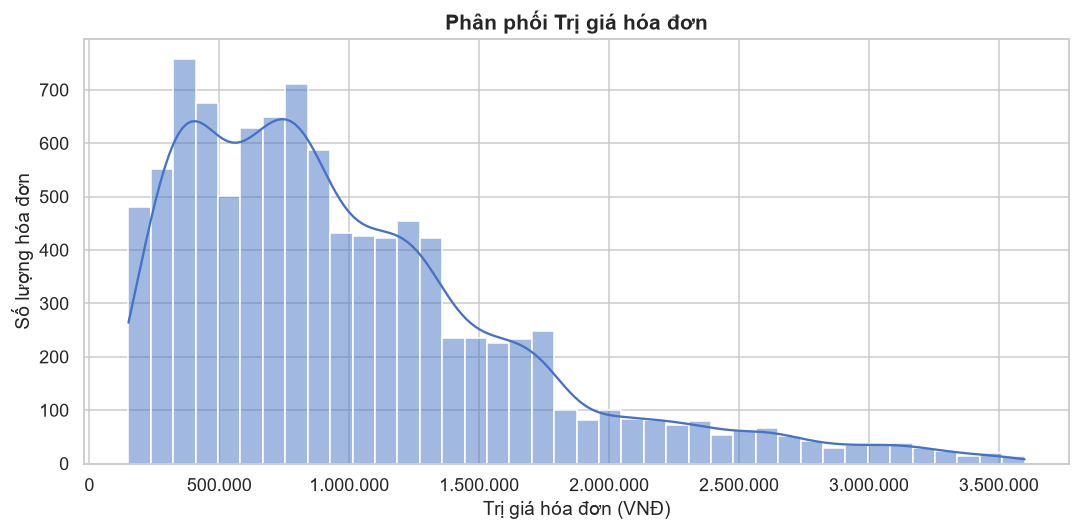

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="Trị giá hóa đơn", bins=40, kde=True, color="#4472C4", ax=ax)

ax.set_title("Phân phối Trị giá hóa đơn", fontsize=14, fontweight="bold")
ax.set_xlabel("Trị giá hóa đơn (VNĐ)")
ax.set_ylabel("Số lượng hóa đơn")
dat_dinh_dang_truc(ax, truc="x")
dat_dinh_dang_truc(ax, truc="y")
plt.tight_layout()
plt.show()


## 6. Phân bố Số lượng khách mỗi bàn

Trực quan hóa so sánh (Comparison) — dùng **Bar Chart** để xem số lượng khách phổ biến nhất.


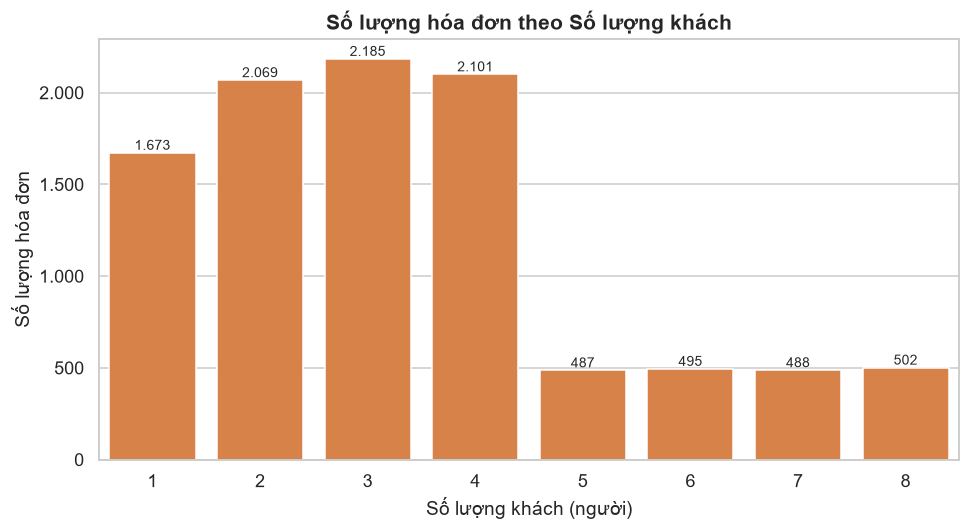

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
thu_tu = sorted(df["Số lượng khách"].unique())
sns.countplot(data=df, x="Số lượng khách", order=thu_tu, color="#ED7D31", ax=ax)

ax.set_title("Số lượng hóa đơn theo Số lượng khách", fontsize=14, fontweight="bold")
ax.set_xlabel("Số lượng khách (người)")
ax.set_ylabel("Số lượng hóa đơn")
dat_dinh_dang_truc(ax, truc="y")

for thanh in ax.patches:
    chieu_cao = thanh.get_height()
    ax.annotate(in_so_vn(chieu_cao), (thanh.get_x() + thanh.get_width() / 2, chieu_cao),
                ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


> **📌 Nhận xét:** Đa số hóa đơn thuộc nhóm **2–4 người** (mỗi mức ~20–22%), đỉnh cao nhất ở 3 người (~21,8%). Nhóm 5–8 người chỉ chiếm ~20% — là thiểu số nhưng lại là nguồn doanh thu cao (xem mục 9).

## 7. Trị giá hóa đơn theo Loại ngày (ngày thường vs cuối tuần)

Dùng **Box Plot** để so sánh phân phối và phát hiện giá trị ngoại lai (outliers) giữa hai nhóm.


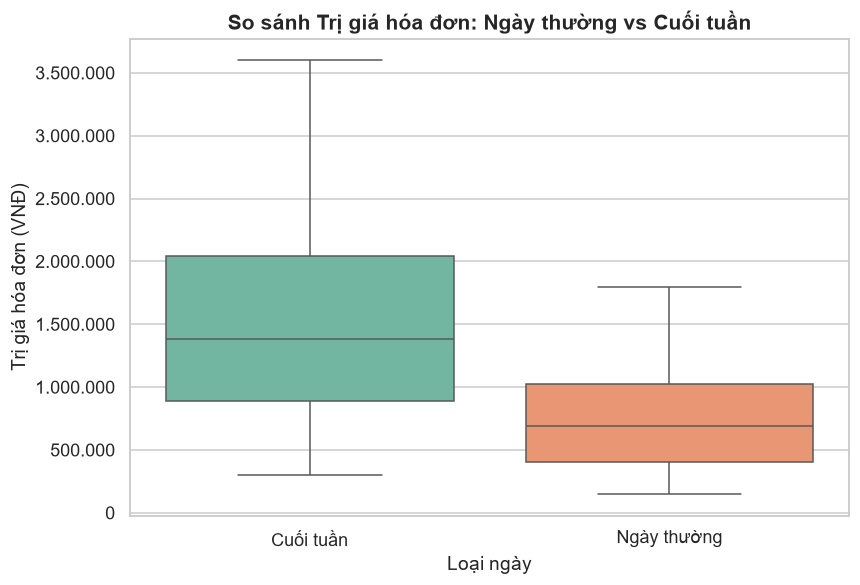

In [7]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sns.boxplot(data=df, x="Loại ngày", y="Trị giá hóa đơn", hue="Loại ngày",
            palette="Set2", legend=False, ax=ax)

ax.set_title("So sánh Trị giá hóa đơn: Ngày thường vs Cuối tuần", fontsize=14, fontweight="bold")
ax.set_xlabel("Loại ngày")
ax.set_ylabel("Trị giá hóa đơn (VNĐ)")
dat_dinh_dang_truc(ax, truc="y")
plt.tight_layout()
plt.show()


## 8. Trị giá hóa đơn theo Hình thức thanh toán

Dùng **Violin Plot** (kết hợp box plot + mật độ phân phối) để so sánh chi tiết hơn giữa các hình thức thanh toán.


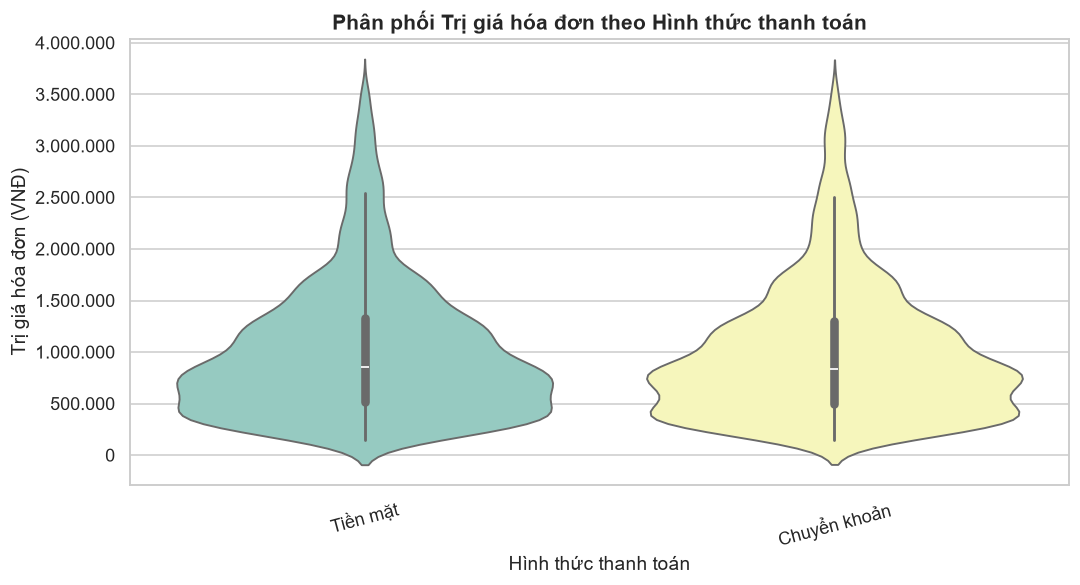

In [8]:
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.violinplot(data=df, x="Thanh toán", y="Trị giá hóa đơn", hue="Thanh toán",
               palette="Set3", legend=False, ax=ax)

ax.set_title("Phân phối Trị giá hóa đơn theo Hình thức thanh toán", fontsize=14, fontweight="bold")
ax.set_xlabel("Hình thức thanh toán")
ax.set_ylabel("Trị giá hóa đơn (VNĐ)")
dat_dinh_dang_truc(ax, truc="y")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 9. Mối quan hệ giữa Số lượng khách và Trị giá hóa đơn

Dùng **Scatter Plot** để tìm tương quan — nhóm khách đông hơn có xu hướng chi tiêu nhiều hơn không?


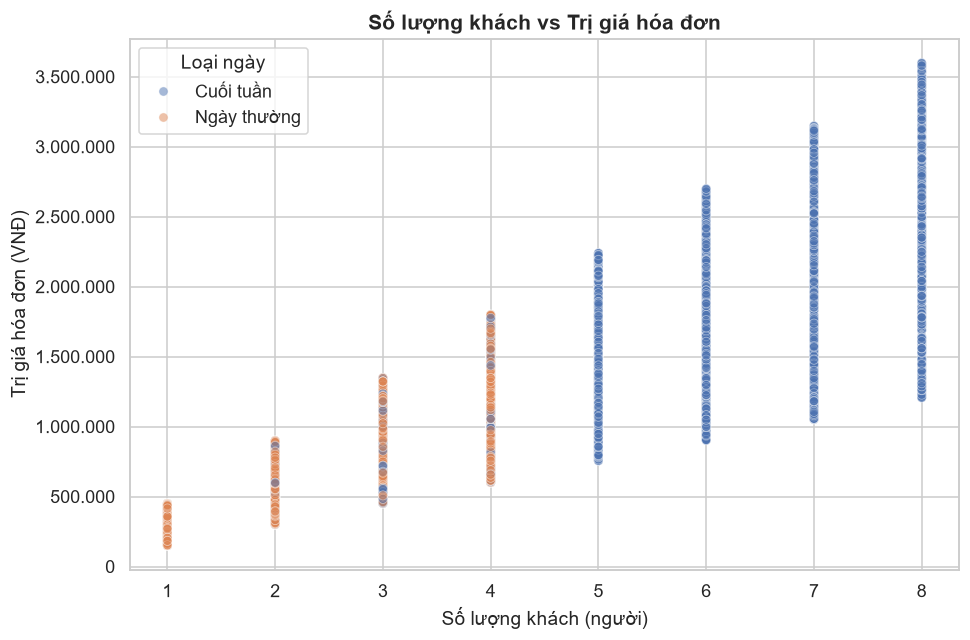

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x="Số lượng khách", y="Trị giá hóa đơn", hue="Loại ngày",
                 alpha=0.5, palette="deep", ax=ax)

ax.set_title("Số lượng khách vs Trị giá hóa đơn", fontsize=14, fontweight="bold")
ax.set_xlabel("Số lượng khách (người)")
ax.set_ylabel("Trị giá hóa đơn (VNĐ)")
dat_dinh_dang_truc(ax, truc="y")
ax.legend(title="Loại ngày")
plt.tight_layout()
plt.show()


> **📌 Nhận xét:** Mối quan hệ **tăng dần rõ rệt và tương quan mạnh (r ≈ +0,86)** — nhóm càng đông thì hóa đơn càng lớn. Nhóm 5–8 người (phía phải) chủ yếu rơi vào cuối tuần, lý giải sự chênh lệch doanh thu giữa hai loại ngày.

## 10. Trị giá hóa đơn trung bình theo Giờ vào

Trực quan hóa **chuỗi thời gian trong ngày** — khung giờ nào khách chi tiêu nhiều nhất (giờ cao điểm)?


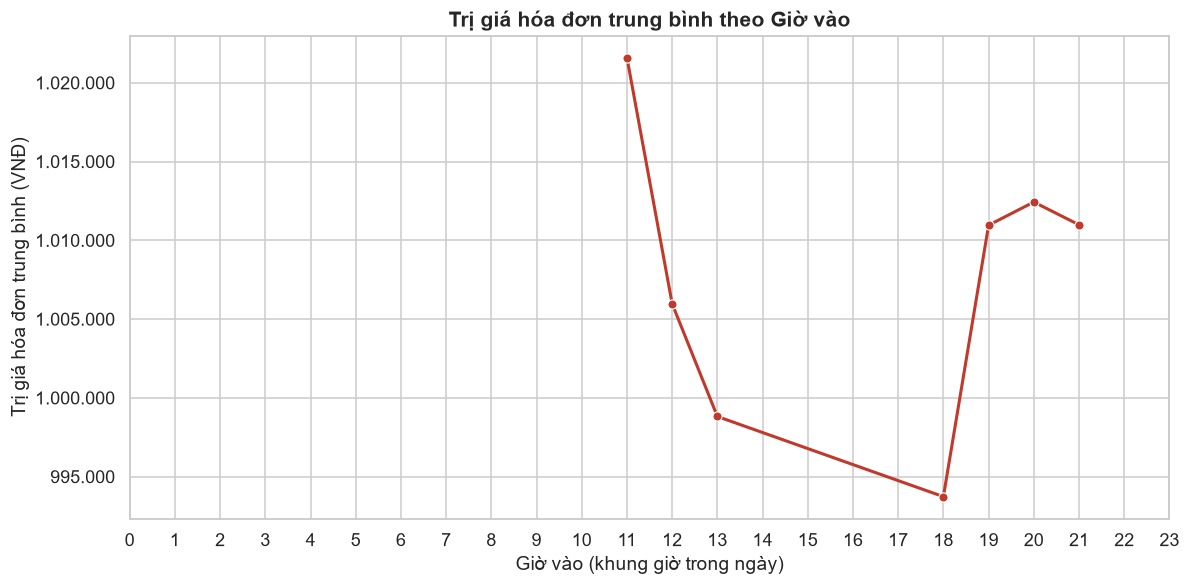

In [10]:
trung_binh_theo_gio = df.groupby("Giờ vào")["Trị giá hóa đơn"].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.lineplot(data=trung_binh_theo_gio, x="Giờ vào", y="Trị giá hóa đơn",
             marker="o", color="#C0392B", linewidth=2, ax=ax)

ax.set_title("Trị giá hóa đơn trung bình theo Giờ vào", fontsize=14, fontweight="bold")
ax.set_xlabel("Giờ vào (khung giờ trong ngày)")
ax.set_ylabel("Trị giá hóa đơn trung bình (VNĐ)")
dat_dinh_dang_truc(ax, truc="y")
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()


> **📌 Nhận xét:** Giá trị trung bình theo giờ rất **phẳng**, dao động quanh ~1,0 triệu ở cả khung trưa (11–13h) và tối (18–21h), không có khung giờ vượt trội. Khách chỉ đến trong 2 cửa sổ chính; giữa trưa và tối không chênh lệch đáng kể về mức chi tiêu.

## 11. Ma trận tương quan giữa các biến định lượng

Dùng **Heatmap** để xem mối liên hệ giữa các biến số trước khi phân tích sâu hơn.


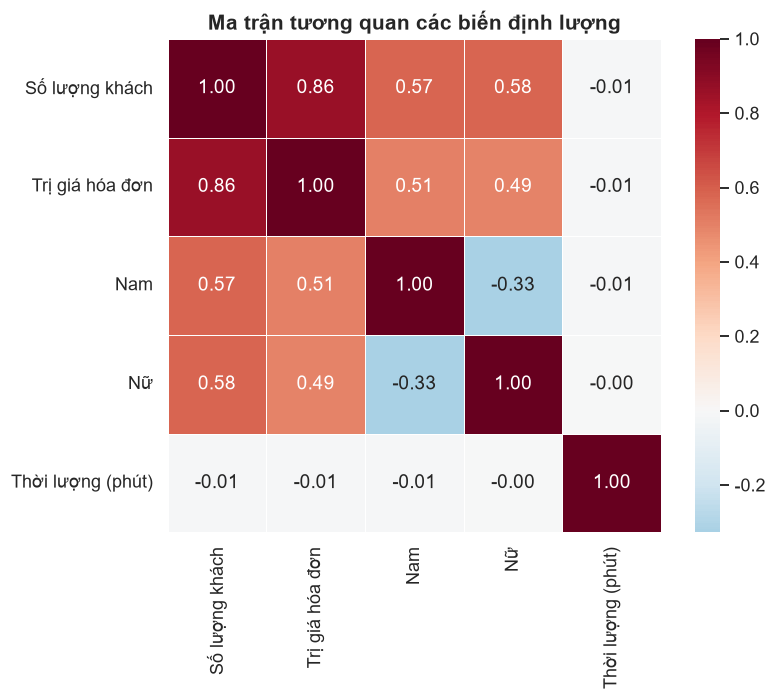

In [11]:
cot_so = ["Số lượng khách", "Trị giá hóa đơn", "Nam", "Nữ", "Thời lượng (phút)"]
ma_tran_tuong_quan = df[cot_so].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(ma_tran_tuong_quan, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax)

ax.set_title("Ma trận tương quan các biến định lượng", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


> **📌 Nhận xét:**
> - **Số lượng khách ↔ Trị giá hóa đơn: +0,86** (mạnh nhất) — quy mô nhóm là yếu tố chính quyết định doanh thu.
> - **Trị giá ↔ Nam (+0,51) và Nữ (+0,49)** tương đương — cả hai giới đều đóng góp như nhau.
> - **Thời lượng dùng bữa ↔ Trị giá gần bằng 0 (−0,01)** — dùng bữa lâu không đi kèm chi tiêu nhiều hơn.

## 12. Cơ cấu giới tính khách hàng theo Loại ngày

Dùng **Stacked Bar Chart** để xem cơ cấu (Composition) Nam/Nữ có khác nhau giữa ngày thường và cuối tuần không.


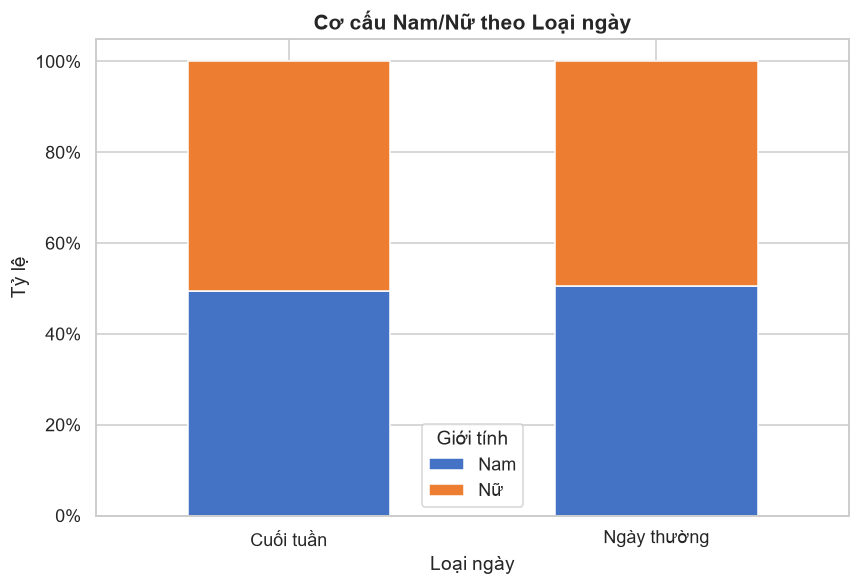

In [12]:
tong_theo_loai_ngay = df.groupby("Loại ngày")[["Nam", "Nữ"]].sum()
ty_le = tong_theo_loai_ngay.div(tong_theo_loai_ngay.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 5.5))
ty_le.plot(kind="bar", stacked=True, color=["#4472C4", "#ED7D31"], ax=ax, width=0.55)

ax.set_title("Cơ cấu Nam/Nữ theo Loại ngày", fontsize=14, fontweight="bold")
ax.set_xlabel("Loại ngày")
ax.set_ylabel("Tỷ lệ")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))
ax.legend(title="Giới tính")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 13. Tổng kết

Notebook đã trực quan hóa dữ liệu nhà hàng theo nhiều góc nhìn:

- **Phân phối** (Distribution): histogram trị giá hóa đơn, box/violin plot theo nhóm
- **So sánh** (Comparison): số lượng khách, trị giá hóa đơn theo loại ngày và hình thức thanh toán
- **Mối quan hệ** (Correlation): scatter plot, ma trận tương quan (heatmap)
- **Chuỗi thời gian** (Time-series): trị giá hóa đơn trung bình theo giờ trong ngày
- **Thành phần tổng thể** (Composition): cơ cấu giới tính theo loại ngày

> **Lưu ý:** đặt file `du_lieu_nha_hang_t11_2025.csv` cùng thư mục với notebook này trước khi chạy, hoặc chỉnh lại biến `duong_dan_file` ở Bước 2 cho đúng đường dẫn thực tế trên máy bạn.
